# Spike Train Reproduction Post-Experiment Analysis

In [1]:
%reload_ext autoreload
%autoreload 2

# Imports
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from tqdm import tqdm
import pickle
import src.utils.preprocess as preprocess
# import src.utils.sigmoid as sigmoid
from scipy.io import savemat, loadmat
from scipy.signal import convolve2d
import re
import visionloader as vl
import sta_utils as su
from scipy.spatial import ConvexHull
import src.utils.cellmap as cellmap
import src.utils.encoding_decoding_simulation_pooled as edsp
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Ellipse
from PIL import Image
import multiprocessing
from multiprocessing import Pool
import warnings

import sys
sys.path.append('/Volumes/Lab/Users/ajphillips/greedy/src/')
import sigmoid

Paths

In [2]:
piece = '2024-09-25-3'
analysis_base = f"/Volumes/Stream/Analysis/RETINA/{piece}"
pp_base = analysis_base
gsort_base = analysis_base
vstim_base = analysis_base
espont_base = analysis_base
pickle_path_base = "gsort_single_v2"
label = ""

In [3]:
# Load response indices
spike_trains = np.load(f"{analysis_base}/dictionary/spike_trains{label}.npz", allow_pickle=True)
response_indices = spike_trains['response_indices']
for i in range(len(response_indices)):
    print(f"Response {i}: {response_indices[i]}")

Response 0: 14
Response 1: 1330
Response 2: 531
Response 3: 1032
Response 4: 1333
Response 5: 1334
Response 6: 635
Response 7: 436
Response 8: 737
Response 9: 338
Response 10: 239
Response 11: 1240
Response 12: 41
Response 13: 542
Response 14: 943
Response 15: 744
Response 16: 1145
Response 17: 1346
Response 18: 947
Response 19: 1048
Response 20: 249
Response 21: 1350
Response 22: 651
Response 23: 1152
Response 24: 553
Response 25: 654
Response 26: 1255
Response 27: 56
Response 28: 357
Response 29: 158
Response 30: 1059
Response 31: 860
Response 32: 761
Response 33: 562
Response 34: 463
Response 35: 1164
Response 36: 265
Response 37: 1166
Response 38: 1267
Response 39: 1368
Response 40: 869
Response 41: 1070
Response 42: 471
Response 43: 1172
Response 44: 973
Response 45: 974
Response 46: 1075
Response 47: 176
Response 48: 577
Response 49: 878
Response 50: 479
Response 51: 780
Response 52: 1281
Response 53: 1282
Response 54: 383
Response 55: 784
Response 56: 1385
Response 57: 1286
Resp

In [241]:
frame_no = 0
response_no = 14
estim_trial = 0
estim = f"data007/frame_{frame_no}"
espont = "data007_from_data003"
vstim = "data005_from_data003"
wnoise = "data003"
cell_types = ['ON parasol', 'OFF parasol']

wnoise_path = os.path.join(analysis_base, wnoise)
pp_path = os.path.join(pp_base, estim)
gsort_path = os.path.join(gsort_base, "gsort", estim, wnoise)
vstim_path = os.path.join(vstim_base, vstim)
espont_path = os.path.join(espont_base, espont)

Single electrode scan info:

In [242]:
wn1 = 'data003'
estim1 = 'data004'
wn2 = 'data003'
estim2 = 'data009'

Load dictionary

In [243]:
# The dictionary and associated data is stored in this directory
# Much of the data/analysis associated with the experiment exists in the parent directory
dict_path = os.path.join(analysis_base, "dictionary")

# Load relevant data from .npz files
with np.load(os.path.join(dict_path,f"selective_stimuli{label}.npz")) as data:
    selective_stimuli = data["selective_stimuli"]
with np.load(os.path.join(dict_path,f"{wnoise}_bundle_thresholds.npz")) as data:
    bundle_thresholds = data["bundle_thresholds"]

print(selective_stimuli.shape)
print(bundle_thresholds.shape)

np.set_printoptions(suppress=True)
print(selective_stimuli)

(301, 4)
(519, 2)
[[   2.         7597.            3.57597269    1.        ]
 [   3.           62.            3.21697526    1.        ]
 [   5.           62.            2.39757895    1.        ]
 ...
 [ 515.           62.            2.72291755    1.        ]
 [ 516.         7713.            3.2508206     1.        ]
 [ 517.           62.            3.66670644    1.        ]]


In [244]:
vcd = vl.load_vision_data(wnoise_path,wn1,
                        include_neurons=True,
                        include_ei=True,
                        include_params=True,
                        include_runtimemovie_params=True)

all_cells_of_interest = []
for cell_type in cell_types:
    all_cells_of_interest += vcd.get_all_cells_similar_to_type(cell_type)
all_cells_of_interest = np.array(all_cells_of_interest)

print(f"Total cells of type {cell_types}: {all_cells_of_interest.size}")

Total cells of type ['ON parasol', 'OFF parasol']: 55


Count the delivered stimuli

In [245]:
# The electrical stimulation scans are stored in this directory
# Much of the data/analysis associated with the experiment exists in the parent directory
path = os.path.join(analysis_base, "estim")

# Read in .mat file
ppinfo = loadmat(os.path.join(path,f"preprocessing_info{label}.mat"))
experiment_boundaries, experiment_names = ppinfo["experimentBoundaries"], ppinfo["experimentNames"]
print(f"Experiment boundaries shape {experiment_boundaries.shape}")

with open(os.path.join(path,f"spike_trains{label}.sef"), "rb") as f:
    sef = np.fromfile(f, dtype=np.int32)
    sef = np.reshape(sef, (int(len(sef)/3), 3), order='F')

sef_of_interest = sef[experiment_boundaries[frame_no,estim_trial*2+0]-1:experiment_boundaries[frame_no,estim_trial*2+1],:] # Assume 2D matrix called 'experimentBoundaries' of size |nExperiments|x|2*nBoundaries|

unique_stimuli, count_stimuli = np.unique(sef_of_interest[:,1:], axis=0, return_counts=True)
unique_times, count_times = np.unique(sef_of_interest[:,0], return_counts=True)

Experiment boundaries shape (105, 30)


In [246]:
print(f"{unique_stimuli.shape[0]} unique stimuli")
print(f"{unique_times.shape[0]} stimulation events")

print(sum(count_stimuli), "total stimulations")
print(f"Duration {(sef_of_interest[-1,0] - sef_of_interest[0,0]) / 20} ms")

44 unique stimuli
290 stimulation events
502 total stimulations
Duration 2242.5 ms


### Load electrically evoked spike trains

In [247]:
def flip(cell, pattern, amp, flip_prob=0.9, plot=False, suppress_warnings=False):

    gsort_path_base1 = os.path.join(gsort_base, "gsort", estim1)
    gsort_path_base2 = os.path.join(gsort_base, "gsort", estim2)

    patterns = sigmoid.find_activating_patterns(gsort_path_base1, cell)
    patterns = np.sort(patterns)
    pattern_nos = [int(p.split('p')[-1]) for p in patterns]
    
    if pattern not in pattern_nos:
        # raise Exception("Pattern not found in gsort_path_base1")
        if not suppress_warnings:
            warnings.warn("Pattern not gsorted during single-electrode stimulation, can't disambiguate") # Note this will only show once if the issue occurs repeatedly
        return False

    pattern = f"p{pattern}"

    try:
        if plot:
            fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(5,5))

        amps1, probs1, slp1, thr1, std1, success1 = sigmoid.compute_sigmoid(gsort_path_base1, pickle_path_base, cell, pattern, plot=False)
        
        if plot:
            sigmoid.plot_sigmoid(ax, amps1, probs1, slp1, thr1, 'k')

        try:
            amps2, probs2, slp2, thr2, std2, success2 = sigmoid.compute_sigmoid(gsort_path_base2, pickle_path_base, cell, pattern) # mapping['forward'][cell]

            if plot:
                sigmoid.plot_sigmoid(ax, amps2, probs2, slp2, thr2, 'b')

        except Exception as e:
            if plot:
                ax.text(0.1,0.9,str(e))
            else:
                raise e

    except Exception as ex:
        if plot:
            ax.text(0.1,0.1,str(ex))
        else:
            raise ex
    
    if plot:
        ax.set_xlim(0,4)
        ax.set_ylim(0,1)
        ax.set_xlabel('Stimulation Amplitude (uA)')
        ax.set_ylabel('Activation Probability')
        ax.set_title(f"{piece} cell {cell} electrode {pattern[1:]}")
        plt.show()

    # Perform disambiguation
    # print(f"calibration prob {probs1[amp-1]}, bookend prob {probs2[amp-1]}, flipping {probs2[amp-1] > flip_prob}")
    if probs2[amp-1] > flip_prob:
        return True
    else:
        return False

In [248]:
def amps_to_indices(amps):
    AMPS = np.array([0.09375, 0.1875, 0.28125, 0.375, 0.46875, 0.5625, 0.65625, 0.75, 0.84375, 0.9375,
        1.03125, 1.125, 1.21875, 1.3125, 1.40625, 1.5, 1.59375, 1.6875, 1.78125, 1.875, 1.96875,
        2.0625, 2.15625, 2.25, 2.34375, 2.4375, 2.53125, 2.625, 2.71875, 2.8125, 2.90625, 3.0,
        3.09375, 3.1875, 3.28125, 3.375, 3.46875, 3.5625, 3.65625, 3.75, 3.84375, 3.9375])
    return np.array([np.argmin(np.abs(AMPS - amp)) + 1 for amp in amps]) # 1-indexed

def boolean_spikes(gsort_path_base, pickle_path_base, cell, pattern, k):
    # Set the random number seed for reproducibility of edge case behavior
    np.random.seed(cell+int(pattern[1:]))

    gsort_path = f"{gsort_path_base}/{pattern}/"
   
    pickle_path = f"{pickle_path_base}_n{cell}_{pattern}_k{k}.pkl"
    with open(gsort_path + pickle_path, 'rb') as f:
        prob_dict = pickle.load(f)
        
        cosine_prob, prob, initial_clustering_with_virtual, final_clustering, graph_info = prob_dict['cosine_prob'], prob_dict['prob'], prob_dict['initial_clustering_with_virtual'], prob_dict['final_clustering'], prob_dict['graph_info']

        cosine_prob = cosine_prob[0]
        graph_info = graph_info[2]
        final_clustering = final_clustering[0]

        # print(cosine_prob)
        # print(prob)
        # print(graph_info)
        # print(initial_clustering_with_virtual)

        if np.isclose(cosine_prob, 0, rtol=0, atol=1e-5):
            bool_spikes = [False for _ in initial_clustering_with_virtual]
            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes

        # get index of dictionary entry with the value cell
        edges = [*graph_info]
        edge = get_key(graph_info, cell)
        # print(edge)
        # print(edges)
        path = []
        for e in edge:
            path.extend(get_path(edges, edges.index(e)))

        # print(path)

        if np.isclose(cosine_prob, prob, rtol=0, atol=1e-5):
            bool_spikes = [spike in path for spike in initial_clustering_with_virtual]
            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes
        

        all_possible_edges = []
        difference = np.round(np.abs(cosine_prob - prob)*len(initial_clustering_with_virtual)).astype(int)
        # print(difference)

        for e in edge:
            _ = find_cosine_path(edges, edges.index(e), initial_clustering_with_virtual, all_possible_edges, difference)
        # print(all_possible_edges)

        if len(all_possible_edges) > 1:
            warnings.warn("Ambiguous cosine similarity single path removal") # we cannot infer which edge was removed, arbitrarily guess the first one
        elif len(all_possible_edges) == 0:
            warnings.warn("No valid cosine similarity single path removal") # indicating multiple edges have been removed, randomly assign the spikes
            
            # Build a randomly shuffled list of booleans corresponding to the cosine probability
            bool_spikes = [True if i < np.round(cosine_prob*len(initial_clustering_with_virtual)).astype(int) else False for i in range(len(initial_clustering_with_virtual))]
            np.random.shuffle(bool_spikes)

            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes
        
        removal_path = get_path(edges, edges.index(all_possible_edges[0]))
        # print(removal_path)

        bool_spikes = [spike in path and spike not in removal_path for spike in initial_clustering_with_virtual]
        # print(bool_spikes)
        # print(sum(bool_spikes)/len(bool_spikes))
        
        return bool_spikes


def get_key(my_dict, val):
    keys = []
   
    for key, value in my_dict.items():
        if val == value:
            keys.append(key)

    if len(keys) == 0:
        raise ValueError("Cell not assigned to any edge")

    return keys

def get_path(edges, start_index):
    path = []
    path.append(edges[start_index][1])

    for i in range(len(edges)):
        if edges[i][0] == edges[start_index][1]:
            path.extend(get_path(edges, i))

    return path
    
def find_cosine_path(edges, start_index, initial_clustering_with_virtual, all_possible_edges, difference):

    count = 0
    for i in range(len(edges)):
        if edges[i][0] == edges[start_index][1]:
            count += find_cosine_path(edges, i, initial_clustering_with_virtual, all_possible_edges, difference)
    
    total = np.sum(edges[start_index][1] == initial_clustering_with_virtual) + count
    if total == difference:
        all_possible_edges.append(edges[start_index])
    return total

def transform_to_519(electrode):
    skip_elecs = np.array([1, 130, 259, 260, 389, 390, 519])
    elecs = np.arange(1, 520)
    elecs = elecs[~np.isin(elecs, skip_elecs)]
    return elecs[electrode-1]


In [249]:
from multiprocessing import Pool

def process_time_pattern(t):
    """Process a single time pattern."""
    local_initial_spikes = {}
    local_initial_probabilities = {}
    local_spikes = {}
    local_probabilities = {}
    local_off_target_counter = 0

    # Set up nested dictionaries
    local_initial_spikes[t] = {}
    local_initial_probabilities[t] = {}
    local_spikes[t] = {}
    local_probabilities[t] = {}

    # Identify all electrical stimuli delivered simultaneously at time t
    stim = sef_of_interest[np.where(sef_of_interest[:, 0] == unique_times[t])[0], 1:]

    target_cells = []
    for s in stim:
        # Find the row of selective_stimuli corresponding to each electrical stimulus
        selective_stimulus = selective_stimuli[np.where((selective_stimuli[:, 0] == transform_to_519(s[0])) & (amps_to_indices(selective_stimuli[:, 2]) == s[1]))[0][0]]

        # Look for electrical spike sorting results at the time-pattern for each targeted cell (only ever one movie per time-pattern)
        c = int(selective_stimulus[1])
        bs = boolean_spikes(gsort_path, pickle_path_base, c, f"p{t+1}", 0)

        local_initial_spikes[t][c] = bs
        local_initial_probabilities[t][c] = np.mean(bs)

        # If the selective stimulus was pure (we expected the cell to spike with ~100% probability) and gsort returns ~0% probability,
        # cross reference with the bookend single-electrode scan to decide how to disambiguate
        # Assumes that multi-electrode stimulation does not significantly alter the single-electrode activation curve
        # Ask Amrith about explanation for 0.1
        if int(selective_stimulus[3]) and (np.mean(bs) < 0.2): 
            if flip(c, transform_to_519(s[0]), s[1], flip_prob=0.8, plot=False): 
                bs = [not b for b in bs]

        local_spikes[t][c] = bs
        local_probabilities[t][c] = np.mean(bs)

        target_cells.append(c)

    # Look for electrical spike sorting results at the time-pattern for each other gsorted cell (only ever one movie per time-pattern)
    for c in sigmoid.find_activating_cells(gsort_path, f"{t+1}"):
        if c in target_cells:
            continue

        bs = boolean_spikes(gsort_path, pickle_path_base, c, f"p{t+1}", 0)

        local_initial_spikes[t][c] = bs
        local_initial_probabilities[t][c] = np.mean(bs)

        # Perform disambiguation:
        # We know that during the calibration scan, the non-target cell was not activated with the electrical stimulus
        # If the bookend scan indicates that the non-target cell was activated with high probability, we assume the worst and flip the result
        # Also assume the worst by trying to disambiguate with each electrical stimulus and taking the largest activation probability
        if np.mean(bs) < 0.2:
            for s in stim:
                if flip(c, transform_to_519(s[0]), s[1], flip_prob=0.8, plot=False, suppress_warnings=True): 
                    bs = [not b for b in bs]
                    break

        local_spikes[t][c] = bs
        local_probabilities[t][c] = np.mean(bs)

        if np.mean(bs) > 0.5:
            print(f"Off-target cell {c} activated at {np.mean(bs)} (expected {target_cells})")
            local_off_target_counter += 1

    return local_initial_spikes, local_initial_probabilities, local_spikes, local_probabilities, local_off_target_counter

# Use multiprocessing to parallelize the loop over t
initial_spikes = {}
initial_probabilities = {}
spikes = {}
probabilities = {}
off_target_counter = 0

with Pool() as pool:
    for result in pool.imap(process_time_pattern, range(unique_times.shape[0])):
        local_initial_spikes, local_initial_probabilities, local_spikes, local_probabilities, local_off_target_counter = result
        initial_spikes.update(local_initial_spikes)
        initial_probabilities.update(local_initial_probabilities)
        spikes.update(local_spikes)
        probabilities.update(local_probabilities)
        off_target_counter += local_off_target_counter

print(f"{off_target_counter / sum(count_stimuli) * 100:.1f}% of stimuli result in off-target activation")

Off-target cell 2270 activated at 1.0 (expected [4143])
Off-target cell 62 activated at 0.8 (expected [1097, 7713])
Off-target cell 632 activated at 0.9333333333333333 (expected [6017])
Off-target cell 632 activated at 1.0 (expected [6017])
Off-target cell 1715 activated at 1.0 (expected [4773])Off-target cell 1715 activated at 1.0 (expected [4773])

Off-target cell 1715 activated at 0.9333333333333333 (expected [4773])
Off-target cell 632 activated at 1.0 (expected [6017])
Off-target cell 1248 activated at 0.9333333333333333 (expected [6678])
Off-target cell 1715 activated at 0.9333333333333333 (expected [4788])
Off-target cell 62 activated at 0.6666666666666666 (expected [7713])
Off-target cell 7713 activated at 1.0 (expected [6649])Off-target cell 1715 activated at 1.0 (expected [4773])

Off-target cell 7713 activated at 1.0 (expected [6649])
Off-target cell 7713 activated at 1.0 (expected [6649])
Off-target cell 2270 activated at 1.0 (expected [4143])
Off-target cell 1715 activated

/tmp/ipykernel_33966/28023764.py:62: UserWarning: Ambiguous cosine similarity single path removal
  warnings.warn("Ambiguous cosine similarity single path removal") # we cannot infer which edge was removed, arbitrarily guess the first one


Off-target cell 1715 activated at 0.8 (expected [1248, 4788, 7247])
Off-target cell 632 activated at 1.0 (expected [6017, 6857])
Off-target cell 632 activated at 1.0 (expected [2734, 6017, 7372])
Off-target cell 1715 activated at 0.8666666666666667 (expected [4788, 5494])
Off-target cell 632 activated at 1.0 (expected [6017])
Off-target cell 632 activated at 1.0 (expected [1715, 6017, 7322, 7698])
Off-target cell 632 activated at 1.0 (expected [965, 2404, 6017])
Off-target cell 1715 activated at 1.0 (expected [4773, 7247, 7372])
Off-target cell 632 activated at 0.9333333333333333 (expected [1697, 6017, 6678])
Off-target cell 1715 activated at 1.0 (expected [1097, 4773, 5929])
Off-target cell 632 activated at 1.0 (expected [965, 1697, 6017])
Off-target cell 632 activated at 1.0 (expected [6017, 7322, 7698])
Off-target cell 632 activated at 1.0 (expected [6017, 6857, 7247, 7322, 7698])
Off-target cell 632 activated at 0.9333333333333333 (expected [1715, 4081, 5492, 6017])
Off-target cell

/tmp/ipykernel_33966/28023764.py:62: UserWarning: Ambiguous cosine similarity single path removal
  warnings.warn("Ambiguous cosine similarity single path removal") # we cannot infer which edge was removed, arbitrarily guess the first one


Off-target cell 1248 activated at 1.0 (expected [632, 2853, 6678])
Off-target cell 1697 activated at 0.8 (expected [1715, 4081, 5492, 6017])
Off-target cell 1248 activated at 1.0 (expected [632, 1579, 2853, 6678])
Off-target cell 2270 activated at 1.0 (expected [62, 965, 2404, 4143, 7322])
Off-target cell 1715 activated at 0.5333333333333333 (expected [4788])
Off-target cell 1248 activated at 1.0 (expected [2853, 4773, 5492, 6678])
Off-target cell 1715 activated at 0.7333333333333333 (expected [333, 661, 4788])
Off-target cell 1715 activated at 0.8 (expected [333, 4788])
Off-target cell 1715 activated at 1.0 (expected [1877, 4773])
Off-target cell 1715 activated at 1.0 (expected [632, 4773])
Off-target cell 1248 activated at 0.9333333333333333 (expected [661, 4038, 6678])
Off-target cell 1715 activated at 1.0 (expected [4773])
Off-target cell 1715 activated at 1.0 (expected [2853, 4773, 5492, 6678])
Off-target cell 1715 activated at 1.0 (expected [2086, 4773, 5492])
Off-target cell 171

### Load visually evoked spike trains

In [250]:
vstim_vcd = vl.load_vision_data(vstim_path,vstim,
                                include_neurons=True)

selective_cells_of_interest = np.unique(selective_stimuli[:,1]).astype(int)
print(f"Total selective cells of type {cell_types}: {selective_cells_of_interest.size}")

# Order selective_cells_of_interest by STA center from leftmost to rightmost
sta_centers = []
for c in selective_cells_of_interest:
        center_x = vcd.get_stafit_for_cell(c).center_x
        center_y = int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c).center_y
        sta_centers.append([center_x, center_y])
sta_centers = np.array(sta_centers)

# Sort left to right
# selective_cells_of_interest = selective_cells_of_interest[np.argsort(sta_centers[:,0])]

# Sort right to left
# selective_cells_of_interest = selective_cells_of_interest[np.argsort(sta_centers[:,0])[::-1]]

# Sort bottom to top
selective_cells_of_interest = selective_cells_of_interest[np.argsort(sta_centers[:,1])]

# Sort top to bottom
# selective_cells_of_interest = selective_cells_of_interest[np.argsort(sta_centers[:,1])[::-1]]


spike_times = np.array([vstim_vcd.get_spike_times_for_cell(c) for c in selective_cells_of_interest], dtype=object) / 20 # convert to ms

ttl_times = vstim_vcd.ttl_times / 20 # convert to ms

responses = []
for j in range(len(ttl_times)-1):
    if j == 1529: # CHANGE ME
        low = ttl_times[j]
        high = ttl_times[j] + 500
        filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
        responses.append(filtered_spike_times)
    else:
        low = ttl_times[j]
        high = ttl_times[j+1]
        filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
        responses.append(filtered_spike_times)
low = ttl_times[-1]
high = ttl_times[-1] + 500
filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
responses.append(filtered_spike_times)

Total selective cells of type ['ON parasol', 'OFF parasol']: 45


In [251]:
# Make sure this index agrees with the frame you are looking at
response = responses[response_no]

In [270]:
# Build electrically evoked response for a single trial using the spike dictionary
estim_response = [[] for _ in range(len(selective_cells_of_interest))]

estim_trial = 1

for t in range(unique_times.shape[0]):
    for c in spikes[t]:
        # Only include selective cells of interest in results for now
        if c not in selective_cells_of_interest:
            continue        
        if spikes[t][c][estim_trial]:
            estim_response[np.where(selective_cells_of_interest == c)[0][0]].append(unique_times[t])

for c in range(len(estim_response)):
    estim_response[c] = np.array(estim_response[c])
estim_response = np.array(estim_response, dtype=object) / 20 # convert to ms

In [225]:
# Align response rasters in time (the very first attempted estim is aligned with the very first rounded recorded vstim spike)
bin_size_ms = 2.5
rounded_response = np.array([np.round(cell_spike_times / bin_size_ms) * bin_size_ms for cell_spike_times in response], dtype=object)

response_reference_candidates = []
for c in range(len(rounded_response)):
    if len(rounded_response[c]) > 0:
        response_reference_candidates.append(rounded_response[c][0])
response_reference = np.min(response_reference_candidates)
print(f"response reference time: {response_reference}")


estim_response_reference = sef_of_interest[0,0] / 20 # convert to ms
print(f"estim response reference time: {estim_response_reference}")

global_reference = response_reference - ttl_times[response_no]
print(f"global reference time: {global_reference}")

response reference time: 611132.5
estim response reference time: 420250.05
global reference time: 39.65000000002328


### Add spontaneous activity to electrically evoked spike trains

In [226]:
espont_vcd = vl.load_vision_data(espont_path,espont,
                                include_neurons=True)

espont_spike_times = np.array([espont_vcd.get_spike_times_for_cell(c) for c in selective_cells_of_interest], dtype=object)

offset = 20000 # offset of 20000 samples between SEF times and actual data
low = unique_times[0] + offset
high = unique_times[-1] + offset
total_response = np.array([(spike_time[(low < spike_time) & (spike_time < high)] - offset) / 20 for spike_time in espont_spike_times], dtype=object) # convert to ms

In [227]:
print(f"All spikes found by Vision are")
for c in range(len(total_response)):
    print(f"Cell {selective_cells_of_interest[c]} spikes: {len(total_response[c])}")

All spikes found by Vision are
Cell 2762 spikes: 0
Cell 3618 spikes: 3
Cell 3381 spikes: 0
Cell 2086 spikes: 0
Cell 2734 spikes: 3
Cell 2091 spikes: 0
Cell 3154 spikes: 1
Cell 2270 spikes: 1
Cell 4038 spikes: 1
Cell 1715 spikes: 1
Cell 2404 spikes: 4
Cell 1697 spikes: 0
Cell 1877 spikes: 4
Cell 4143 spikes: 0
Cell 3332 spikes: 0
Cell 2853 spikes: 1
Cell 1579 spikes: 3
Cell 1592 spikes: 10
Cell 1248 spikes: 13
Cell 4081 spikes: 0
Cell 2478 spikes: 3
Cell 4773 spikes: 0
Cell 1097 spikes: 3
Cell 4788 spikes: 0
Cell 965 spikes: 0
Cell 661 spikes: 1
Cell 5494 spikes: 0
Cell 6678 spikes: 1
Cell 5387 spikes: 2
Cell 632 spikes: 0
Cell 7372 spikes: 0
Cell 5492 spikes: 0
Cell 333 spikes: 2
Cell 7597 spikes: 0
Cell 7322 spikes: 0
Cell 5929 spikes: 5
Cell 62 spikes: 0
Cell 6017 spikes: 0
Cell 7713 spikes: 2
Cell 6857 spikes: 27
Cell 6331 spikes: 1
Cell 6649 spikes: 4
Cell 7698 spikes: 0
Cell 7247 spikes: 0
Cell 7098 spikes: 6


In [228]:
# Get rid of any electrically evoked spikes identified by Vision
# espont_response = [[] for _ in range(len(total_response))]
# for c in range(len(total_response)):
#     espont_response[c] = np.array([spike for spike in total_response[c] if not np.any(((spike - estim_response[c]) >= -1) & ((spike - estim_response[c]) <= 2))])
# espont_response = np.array(espont_response, dtype=object)

In [229]:
# Get rid of any electrically evoked spikes identified by Vision
espont_response = [[] for _ in range(len(total_response))]
for c in range(len(total_response)):
    espont_response[c] = np.array([spike for spike in total_response[c] if not np.any(((spike - unique_times/20) >= -1) & ((spike - unique_times/20) <= 2))])
espont_response = np.array(espont_response, dtype=object)

In [230]:
print(f"Spontaneous spikes found by Vision are")
for c in range(len(espont_response)):
    print(f"Cell {selective_cells_of_interest[c]} spikes: {len(espont_response[c])}")

Spontaneous spikes found by Vision are
Cell 2762 spikes: 0
Cell 3618 spikes: 1
Cell 3381 spikes: 0
Cell 2086 spikes: 0
Cell 2734 spikes: 3
Cell 2091 spikes: 0
Cell 3154 spikes: 0
Cell 2270 spikes: 0
Cell 4038 spikes: 0
Cell 1715 spikes: 1
Cell 2404 spikes: 1
Cell 1697 spikes: 0
Cell 1877 spikes: 0
Cell 4143 spikes: 0
Cell 3332 spikes: 0
Cell 2853 spikes: 0
Cell 1579 spikes: 0
Cell 1592 spikes: 2
Cell 1248 spikes: 1
Cell 4081 spikes: 0
Cell 2478 spikes: 2
Cell 4773 spikes: 0
Cell 1097 spikes: 0
Cell 4788 spikes: 0
Cell 965 spikes: 0
Cell 661 spikes: 1
Cell 5494 spikes: 0
Cell 6678 spikes: 0
Cell 5387 spikes: 1
Cell 632 spikes: 0
Cell 7372 spikes: 0
Cell 5492 spikes: 0
Cell 333 spikes: 0
Cell 7597 spikes: 0
Cell 7322 spikes: 0
Cell 5929 spikes: 2
Cell 62 spikes: 0
Cell 6017 spikes: 0
Cell 7713 spikes: 2
Cell 6857 spikes: 0
Cell 6331 spikes: 1
Cell 6649 spikes: 3
Cell 7698 spikes: 0
Cell 7247 spikes: 0
Cell 7098 spikes: 2


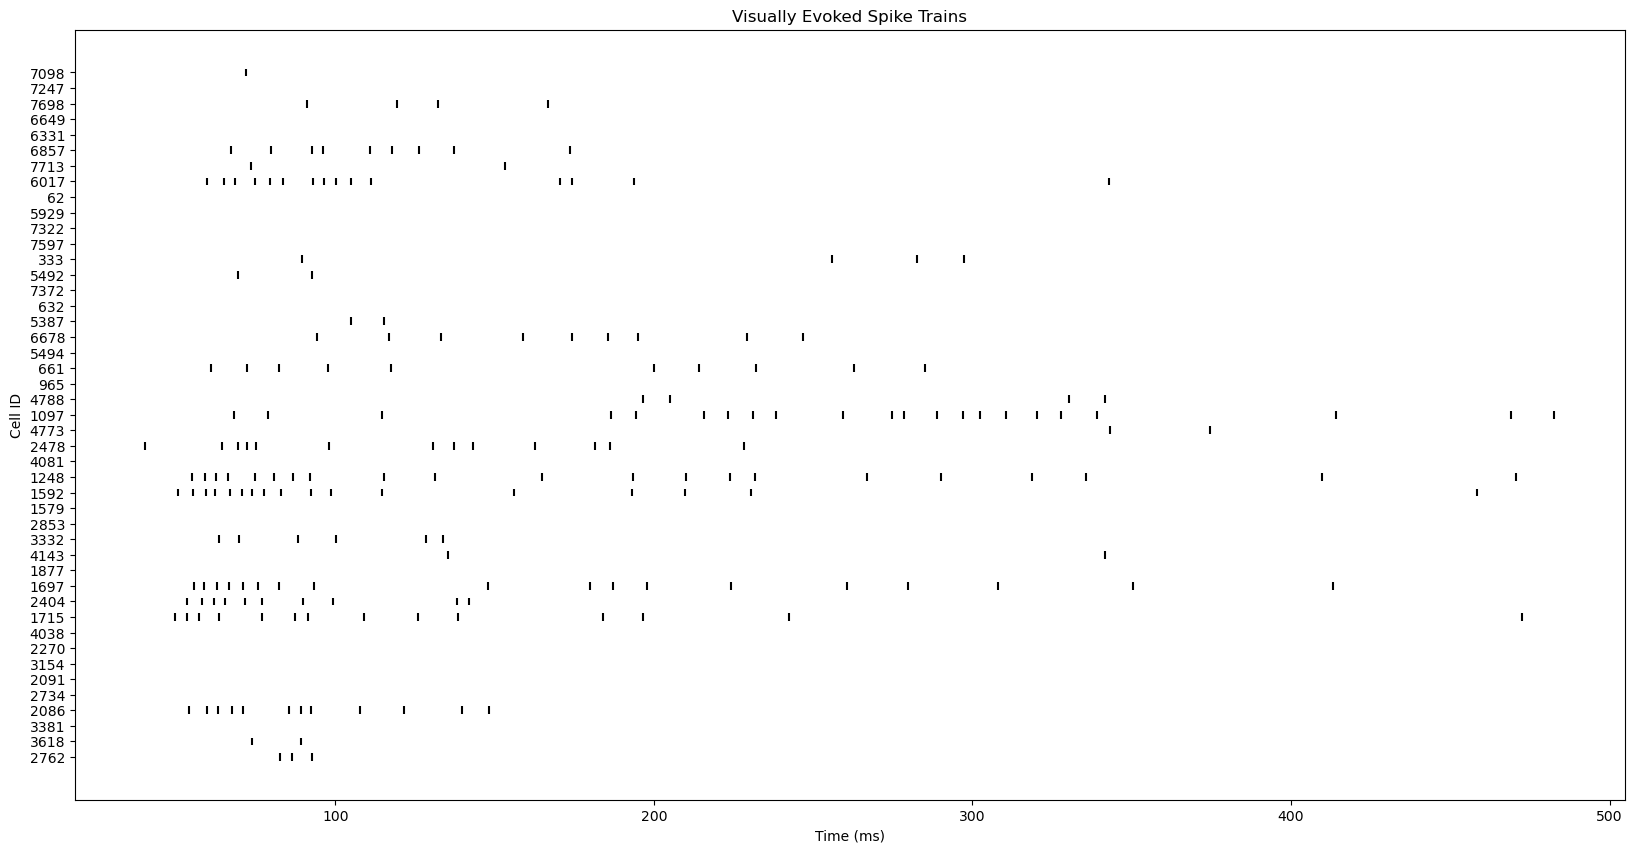

In [231]:
plt.figure(figsize=(20, 10))

# Create a spike raster plot
plt.eventplot(response-response_reference+global_reference, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Visually Evoked Spike Trains')

# Restrict the x axis
# plt.xlim(0, 500)

# Show the plot
plt.show()

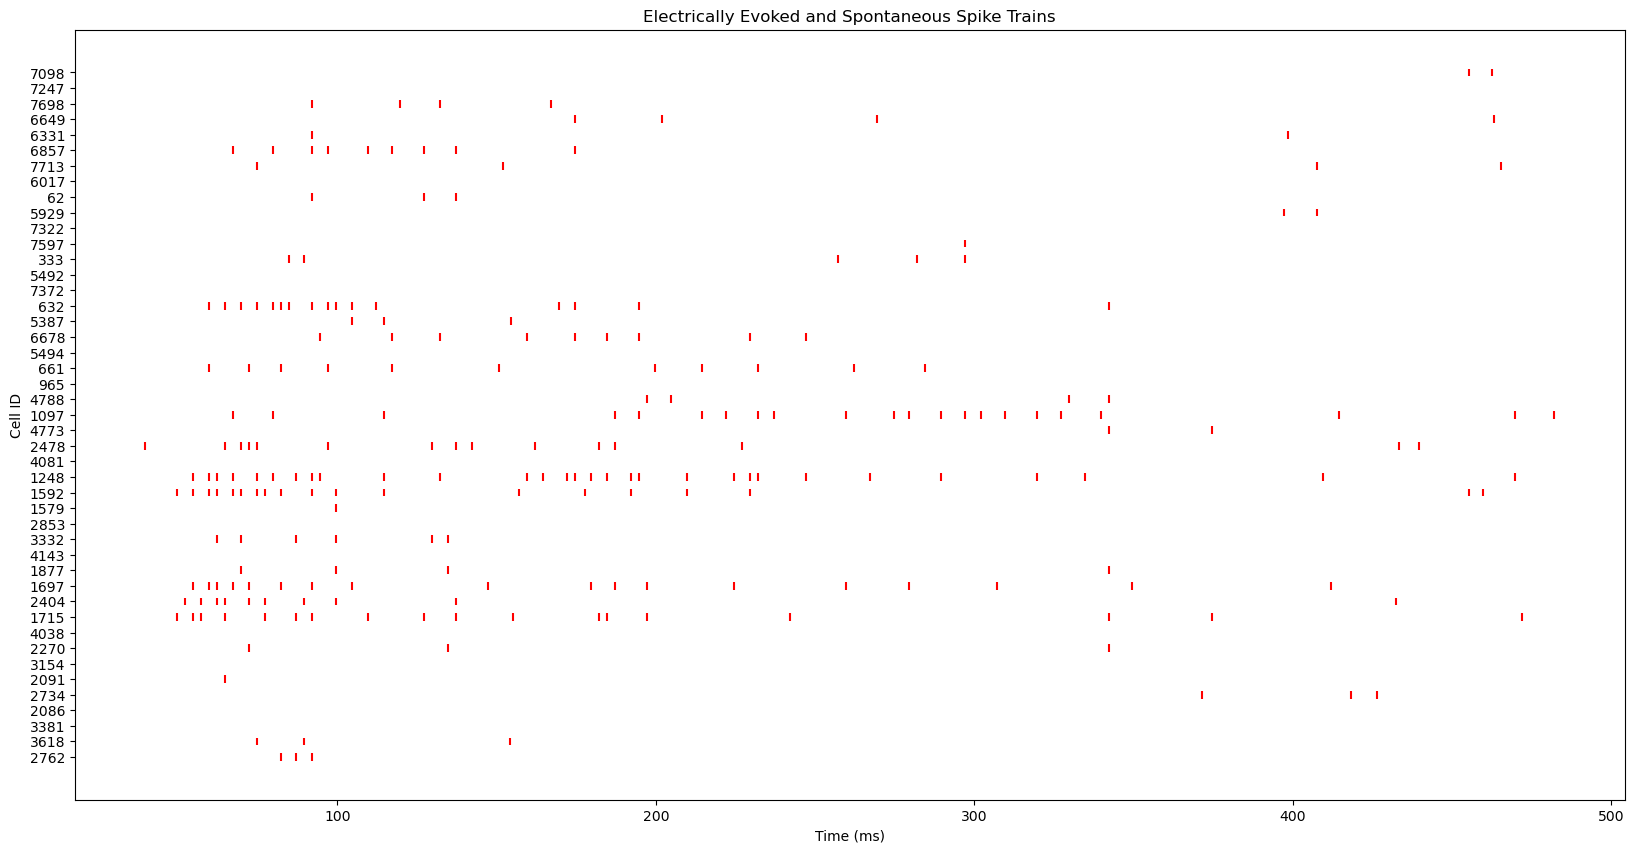

In [232]:
plt.figure(figsize=(20, 10))

# Create a spike raster plot
plt.eventplot(estim_response-estim_response_reference+global_reference, linelengths=0.5, colors='red')
plt.eventplot(espont_response-estim_response_reference+global_reference, linelengths=0.5, colors='red')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Electrically Evoked and Spontaneous Spike Trains')

# Restrict the x axis
# plt.xlim(0, 500)

# Show the plot
plt.show()

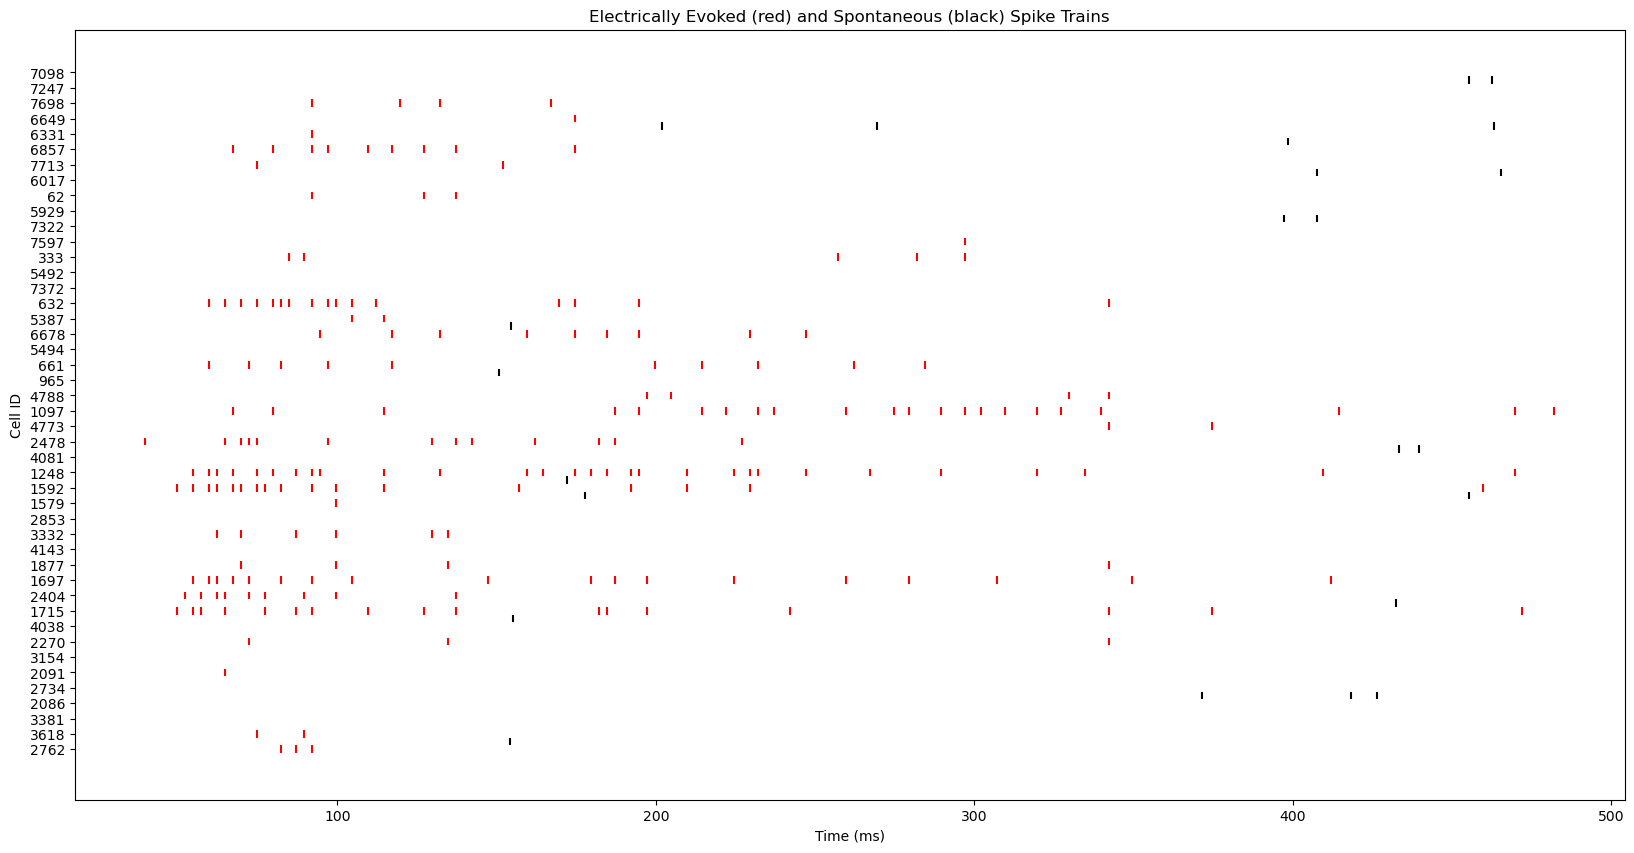

In [233]:
plt.figure(figsize=(20, 10))

# Make two lineoffsets vectors offset by a constant value
lineoffsets1 = np.arange(len(selective_cells_of_interest))
lineoffsets2 = np.arange(len(selective_cells_of_interest)) - 0.5

# Create a spike raster plot
plt.eventplot(estim_response-estim_response_reference+global_reference, linelengths=0.5, lineoffsets=lineoffsets1, colors='red')
plt.eventplot(espont_response-estim_response_reference+global_reference, linelengths=0.5, lineoffsets=lineoffsets2, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Electrically Evoked (red) and Spontaneous (black) Spike Trains')

# Restrict the x axis
# plt.xlim(0, 500)

# Show the plot
plt.show()

### Put it all together and make the money figure

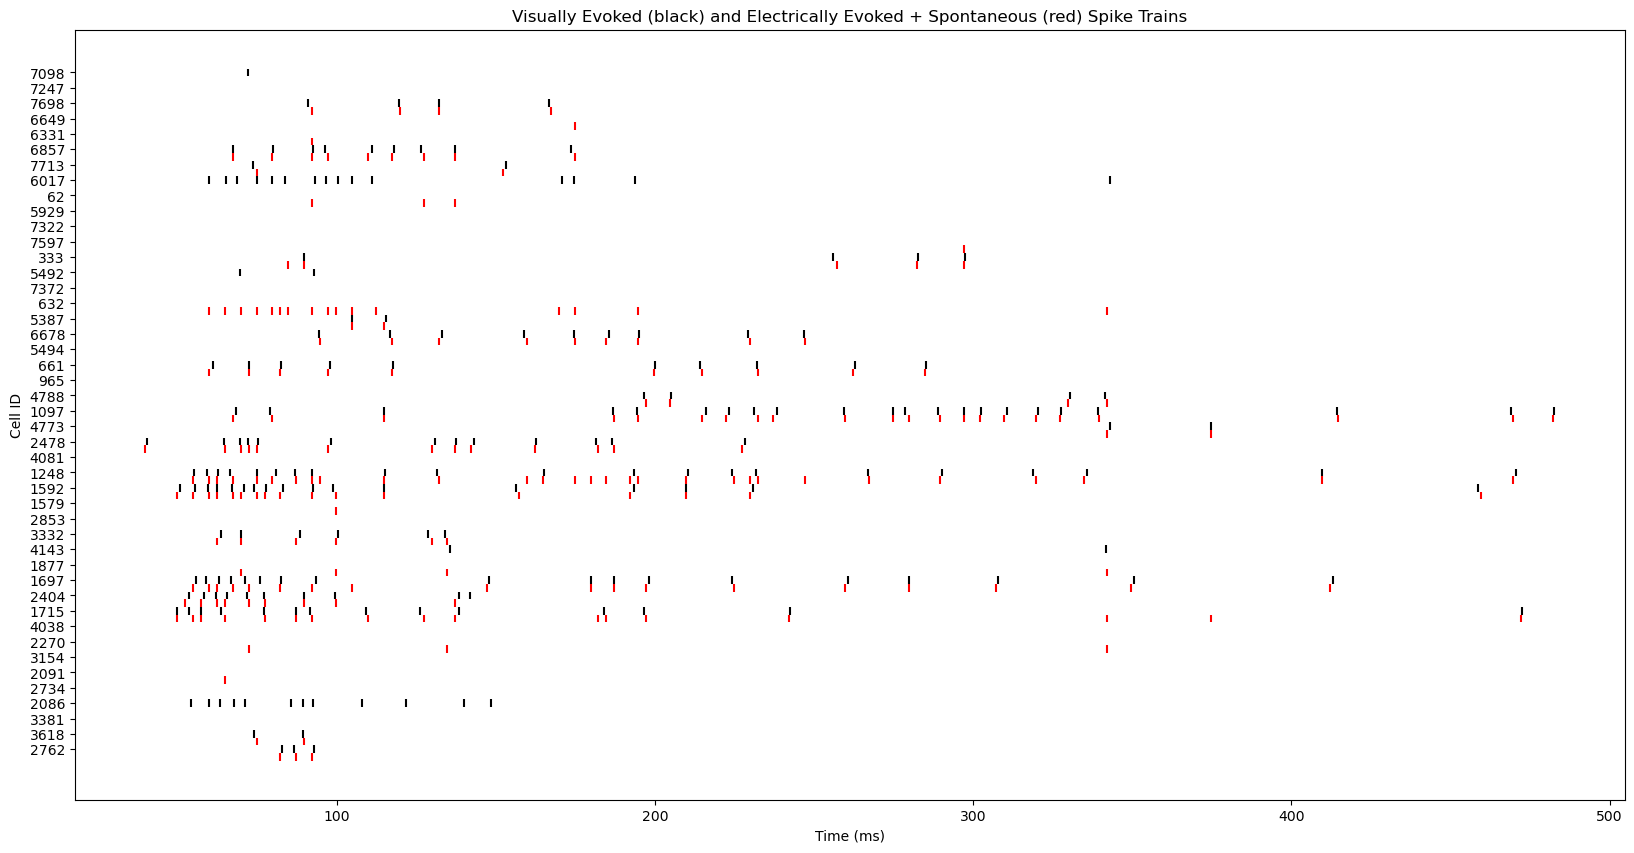

In [234]:
plt.figure(figsize=(20, 10))

# Make two lineoffsets vectors offset by a constant value
lineoffsets1 = np.arange(len(selective_cells_of_interest))
lineoffsets2 = np.arange(len(selective_cells_of_interest)) - 0.5

# Create a spike raster plot
plt.eventplot(response-response_reference+global_reference, linelengths=0.5, lineoffsets=lineoffsets1, colors='black')
plt.eventplot(estim_response-estim_response_reference+global_reference, linelengths=0.5, lineoffsets=lineoffsets2, colors='red')
# plt.eventplot(espont_response-estim_response_reference+global_reference, linelengths=0.5, lineoffsets=lineoffsets2, colors='red')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Visually Evoked (black) and Electrically Evoked + Spontaneous (red) Spike Trains')

# Restrict the x axis
# plt.xlim(0, 500)

# Show the plot
plt.show()

In [134]:
# Find which selective stimulus was used for cell 2312
subset = selective_stimuli[np.where(selective_stimuli[:,1] == 6017)[0]]
print(subset)

[[ 384.         6017.            1.45965797    1.        ]
 [ 411.         6017.            3.57272112    1.        ]]


In [135]:
ordering = []
for row in sef_of_interest:
    if transform_to_519(row[1]) in subset[:,0]:
        ordering.append(transform_to_519(row[1]))
print(ordering)

[411, 411, 411, 411, 411, 411, 411, 411, 411, 411, 411, 411, 411, 411, 411, 411, 411]


In [76]:
print(AMPS[bundle_thresholds[np.where(bundle_thresholds[:,0] == 54)[0][0]][1].astype(int)])

1.03125


In [75]:
AMPS = np.array([0.09375, 0.1875, 0.28125, 0.375, 0.46875, 0.5625, 0.65625, 0.75, 0.84375, 0.9375,
    1.03125, 1.125, 1.21875, 1.3125, 1.40625, 1.5, 1.59375, 1.6875, 1.78125, 1.875, 1.96875,
    2.0625, 2.15625, 2.25, 2.34375, 2.4375, 2.53125, 2.625, 2.71875, 2.8125, 2.90625, 3.0,
    3.09375, 3.1875, 3.28125, 3.375, 3.46875, 3.5625, 3.65625, 3.75, 3.84375, 3.9375])

def transform_to_519_list(patterns):
    skip_elecs = np.array([1, 130, 259, 260, 389, 390, 519])
    elecs = np.arange(1, 520)
    elecs = elecs[~np.isin(elecs, skip_elecs)]

    electrodes = []
    for pattern in patterns:
        electrodes.append(elecs[pattern-1])
    return np.array(electrodes)